<a href="https://colab.research.google.com/github/thrishaa-112/Machine-Learning/blob/main/Loan_Approval_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

In [2]:
df = pd.read_csv("/content/loan_dataset.csv")

In [3]:
print(df.head())

    Loan_ID Gender Married  Dependents     Education Self_Employed  \
0  LP001002   Male      No           0      Graduate            No   
1  LP001003   Male     Yes           1      Graduate            No   
2  LP001005   Male     Yes           0      Graduate           Yes   
3  LP001006   Male     Yes           0  Not Graduate            No   
4  LP001008   Male      No           0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                  0         146               360   
1             4583               1508         128               360   
2             3000                  0          66               360   
3             2583               2358         120               360   
4             6000                  0         141               360   

   Credit_History Property_Area Loan_Status  
0               1         Urban           Y  
1               1         Rural           N  
2             

In [4]:
df.fillna(method='ffill', inplace=True)

/tmp/ipykernel_630/3970806690.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


In [5]:
le = LabelEncoder()

cols = ['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']
for col in cols:
    df[col] = le.fit_transform(df[col])


In [6]:
df['Dependents'] = df['Dependents'].replace('3+', 3).astype(int)


In [7]:
df.drop('Loan_ID', axis=1, inplace=True)

In [8]:
X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']


In [13]:
print(y.value_counts())

Loan_Status
1    5
0    1
Name: count, dtype: int64


In [14]:
model = LogisticRegression(max_iter=1000)
model.fit(X, y)

LogisticRegression(max_iter=1000)

In [15]:
y_pred = model.predict(X_test)

In [16]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 1.0


In [18]:
new_data = np.array([[1, 1, 0, 0, 0, 5000, 0, 120, 360, 1, 2]])

prediction = model.predict(new_data)

if prediction[0] == 1:
    print("Loan Approved ")
else:
    print("Loan Not Approved ")

Loan Approved 


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


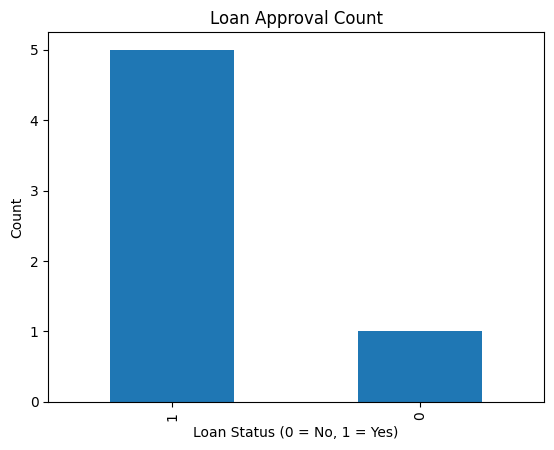

In [19]:
df['Loan_Status'].value_counts().plot(kind='bar')
plt.title("Loan Approval Count")
plt.xlabel("Loan Status (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

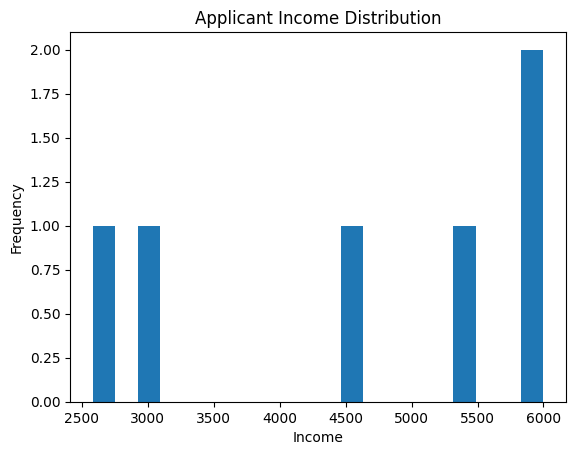

In [20]:
plt.hist(df['ApplicantIncome'], bins=20)
plt.title("Applicant Income Distribution")
plt.xlabel("Income")
plt.ylabel("Frequency")
plt.show()

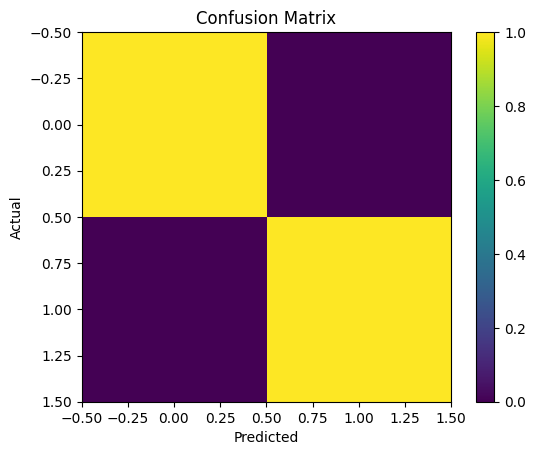

In [21]:
cm = confusion_matrix(y_test, y_pred)
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()